# Causal Lab: ATE Recovery Under Controlled DGP with Observable Confounders

This notebook evaluates five causal estimators on their ability to recover a
known average treatment effect (ATE) from synthetic data. All data is generated
from controlled DGPs where the true ATE is fixed at $2.0$ and all relevant
covariates are observed by construction. The question is not whether we have the
right variables (we do!) but whether standard methods can exploit them correctly
under different structural conditions.

This is the selection-on-observables setting. There are no unobserved confounders,
no instruments, no panel structure. Just $X$, $T$, and $Y$, and the challenge of
recovering the causal effect of $T$ on $Y$ when the assignment mechanism and
outcome surface take different forms. Even in this idealised setting, naive methods
fail. The scenarios below show how and why.

---

## Scenarios

We examine three DGP scenarios, each isolating a distinct source of estimator
stress:

1. **Overlap Degradation** — treatment assignment propensity becomes increasingly
   deterministic as a function of covariates, degrading the common support region
   required for credible comparisons between treated and untreated units.

2. **Outcome Nonlinearity** — the outcome surface transitions from purely linear
   to fully nonlinear via a mixing parameter, stress testing estimators
   that rely on correct functional form specification.

3. **High Dimensionality** — the covariate space grows while the number of truly informative covariates remains fixed. This tests whether estimators can    separate signal from correlated noise as the variable space expands.

Each scenario introduces a single knob that modulates intensity from mild to
severe, holding everything else fixed. This allows estimator failures to be
attributed cleanly to the structural feature under study.

All DGP functions are implemented in `src/dgp_functions.py` and imported into the notebook at the
start of each scenario section.

---

## Estimator Suite

We evaluate five estimators spanning the spectrum from naive baselines to doubly robust and cross-fitted methods, chosen to represent increasing levels of robustness to DGP misspecification.

- **Ordinary Least Squares (OLS)** regresses $Y$ on $T$ and $X$ using `statsmodels.OLS` and reads off
  the coefficient on $T$. It is the natural econometric baseline: include all
  controls in a linear model and assume the functional form is correct. It uses
  no propensity score and assumes the confounding relationship is additive and
  linear.

- **Inverse Probability Weighting (IPW)** estimates propensity scores using `sklearn.LogisticRegression` and
  constructs Horvitz-Thompson weights. Each unit's outcome is upweighted by the
  inverse of its treatment probability, rebalancing the sample so treated and
  control groups look comparable on average. It uses no outcome model. Propensity
  scores are clipped to $[0.05, 0.95]$ to prevent weight explosion near the
  boundary.

- **Flexible Regression Outcome (RO)** is a T-learner built on two `sklearn.RandomForestRegressor`
  models, one trained on treated units and one on controls. Predicted potential
  outcomes are generated for every unit under both treatment values and the ATE
  is their average difference. It allows a flexible, nonparametric outcome surface
  but applies no correction for selection into treatment.

- **Augmented IPW (AIPW)** is implemented via `econml.dr.LinearDRLearner` with a
  `LogisticRegression` propensity model and `LassoCV` outcome model. It augments
  the IPW estimator with an outcome model correction, making it doubly robust:
  consistent if either the propensity or outcome model is correctly specified.
  Cross-fitting across five folds is handled internally by `econml`.

- **Double Machine Learning (DML)** is implemented via `econml.dml.LinearDML` with `LassoCV` for both
  outcome and treatment nuisance models. Rather than reweighting by propensity
  scores, it partials out the effect of $X$ from both $Y$ and $T$ separately
  using cross-fitted regressions, then estimates the treatment effect on the
  residuals. This avoids direct propensity weighting and is designed to handle
  high-dimensional and nonlinear nuisance functions.

Specifications are fixed across all scenarios so that
any differences in performance are attributable to the estimator, not tuning
choices.

All estimators are implemented in `src/ate_suite.py` and share the interface
`fn(Y, T, X) -> float`. 

---

## Key Findings

**Scenario 1: Overlap Degradation**  
When overlap is strong, all five estimators appear to recover the true ATE reasonably well. As overlap weakens, their performance becomes more differentiated. OLS appears comparatively stable throughout, remaining close to zero bias when the main confounder is directly controlled in a linear specification. IPW deteriorates as propensity scores become more extreme and the estimate becomes more sensitive to a relatively small number of heavily weighted observations. Flexible RO shows the largest increase in bias, which is consistent with growing difficulty in predicting counterfactual outcomes across increasingly separated regions of the covariate space. AIPW remains close to unbiased over much of the grid, although its RMSE rises at higher $\gamma$, suggesting reduced stability as overlap worsens. DML also appears comparatively robust, with relatively limited deterioration across the overlap range.

**Scenario 2: Outcome Nonlinearity**  
When the outcome surface is linear, all estimators perform well. As nonlinearity increases, their behaviour becomes more differentiated. OLS shows the clearest accumulation of bias as functional form misspecification grows. IPW is comparatively unaffected, since it does not rely on an outcome model and remains fairly stable across the grid. Flexible RO improves relative to the linear methods as nonlinearity becomes more pronounced, suggesting that its forest-based outcome models are better able to adapt to more complex surfaces. AIPW maintains relatively small bias over much of the range, although its RMSE rises as the outcome model becomes harder to estimate well. DML remains close to zero bias throughout and appears broadly robust; replacing `LassoCV` with a random forest produces a slightly flatter mean trace, suggesting that nuisance model choice still matters, but more at the margin than as a fundamental change in performance (incontext of these simulations).

**Scenario 3: High Dimensionality**  
When the covariate space is low-dimensional, most estimators perform reasonably well. As additional correlated but non-causal covariates are introduced, their performance becomes more differentiated. OLS remains the most stable in this setting, which is consistent with the linear DGP favouring a correctly specified linear adjustment. IPW deteriorates gradually as propensity estimation becomes less clean in the presence of many noise covariates. Flexible RO carries the highest bias throughout and worsens steadily with dimensionality, suggesting that its outcome models do not isolate the small informative subset especially well. AIPW remains fairly stable through moderate dimensionality, but deteriorates noticeably in the highest-dimensional settings. DML also worsens as $p$ grows, with increasingly negative bias and rising RMSE, suggesting that regularisation helps but does not fully protect the nuisance models from the growing noise-to-signal ratio in this design.

---

**Disclaimer:** This project is an exploratory experiment. All results are specific to the DGP specifications, sample sizes, estimator implementations, and random seeds used here. Different settings, data structures, or implementation choices will produce different results, and findings may not hold under alternative configurations. Nothing here should be interpreted as a general or theoretical conclusion about the relative performance of any estimator.

In [1]:
import numpy as np

TRUE_ATE = 2.0
SEED=89

## Scenario 1: Overlap Degradation

A core assumption in the selection-on-observables framework is that every unit
has a non-zero probability of receiving either treatment value, given its
covariates. This is the overlap assumption, sometimes called positivity. When it
holds, treated and untreated units with similar covariate profiles can be
meaningfully compared. When it fails, estimators are forced to extrapolate across
regions of covariate space where one group is absent, and any estimate of the
treatment effect becomes unreliable regardless of how sophisticated the method is.

We degrade overlap via a single parameter $\gamma$ that scales the log-odds of
treatment assignment. At low $\gamma$ treatment is close to random. As $\gamma$
increases assignment becomes increasingly deterministic, pushing propensity scores
toward 0 and 1 and shrinking the region of common support.

The sections below set out the DGP, the distribution of propensity scores across
$\gamma$ values, and estimator performance in terms of bias and RMSE.

### 1a - Data Generating Process

The DGP for this scenario is implemented in `make_overlap_dgp` in `src/dgp_functions.py`. It takes `n`, `gamma`, `true_ate`, and `seed` as inputs and returns `(Y, T, X, ps)`.

**Covariates:** $X \in \mathbb{R}^{10}$ are drawn independently from $\mathcal{N}(0,1)$, with different covariates entering the treatment and outcome models:

- $X_0$ — shared confounder, enters both treatment and outcome
- $X_4$, $X_5$ — treatment only
- $X_1$, $X_2$, $X_3$ — outcome only
- $X_6$ through $X_9$ — inactive noise

**Treatment assignment** follows a logistic propensity model scaled by $\gamma$:

$$ps_i = \sigma\bigl(\gamma \cdot (X_{i0} + 0.3\, X_{i4} - 0.2\, X_{i5})\bigr), \qquad T_i \sim \text{Bernoulli}(ps_i)$$

When $\gamma$ is small,  the propensity scores tend to remain concentrated near 0.5, so treated and control units are more similar in terms of treatment probability. As $\gamma$ increases, the score distribution becomes more dispersed and the two groups tend to separate more clearly. 

We consider eight values:
$\gamma \in \{0.1, 0.25, 0.5, 0.75, 1, 1.5, 2.5, 5\}$ spanning near-random to highly concentrated assignment.

**Outcome** is nonlinear in covariates but fixed across all $\gamma$:

$$Y_i = 2.0 \cdot T_i + 3X_{i0} + 2X_{i1}^2 + 1.5\, X_{i0} X_{i2} + 2\sin(X_{i3}) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,1)$$

This means the outcome model remains equally nonlinear throughout, while $\gamma$ is used to vary the degree of overlap across scenarios.

The figure below shows the empirical propensity score distributions for treated and control units across the eight $\gamma$ values.

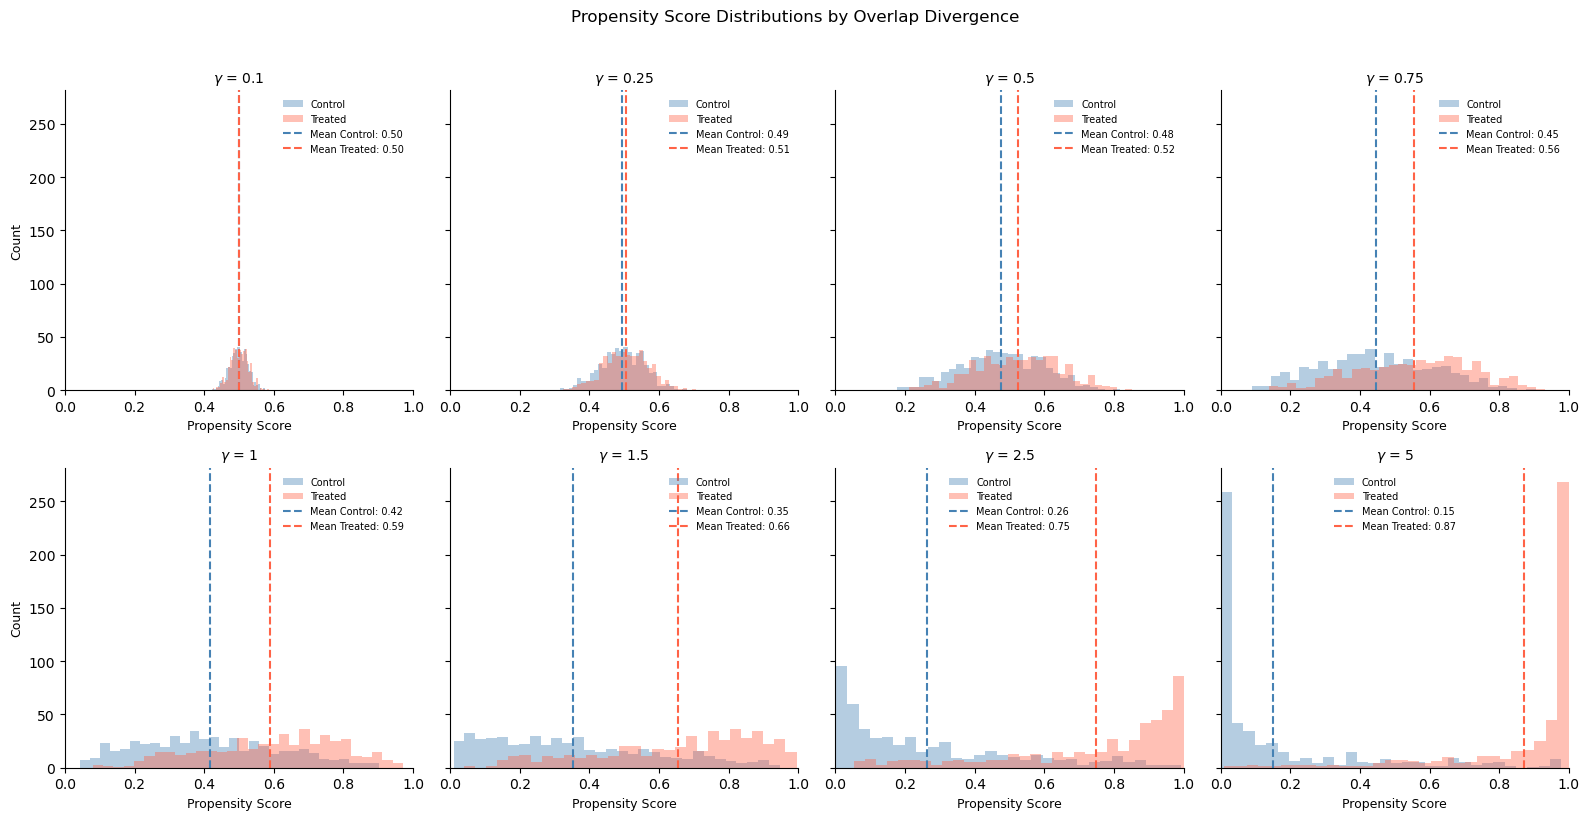

In [2]:
import sys
sys.path.append("src")
from dgp_functions import make_overlap_dgp, TRUE_ATE, SEED
import matplotlib.pyplot as plt

N      = 1000

# gamma values defining the overlap degradation spectrum
GAMMAS = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2.5, 5]

# plot propensity score distributions for treated and control at each gamma
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()

for ax, gamma in zip(axes, GAMMAS):
    Y, T, X, ps = make_overlap_dgp(gamma=gamma, seed=SEED)

    mean_ctrl    = ps[T == 0].mean()
    mean_treated = ps[T == 1].mean()

    ax.hist(ps[T == 0], bins=30, alpha=0.4, label="Control",
            color="steelblue", edgecolor="none")
    ax.hist(ps[T == 1], bins=30, alpha=0.4, label="Treated",
            color="tomato", edgecolor="none")
    ax.axvline(mean_ctrl, color="steelblue", linewidth=1.5, linestyle="--",
               label=f"Mean Control: {mean_ctrl:.2f}")
    ax.axvline(mean_treated, color="tomato", linewidth=1.5, linestyle="--",
               label=f"Mean Treated: {mean_treated:.2f}")
    ax.set_title(f"$\\gamma$ = {gamma}", fontsize=10)
    ax.set_xlabel("Propensity Score", fontsize=9)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Count", fontsize=9)
axes[4].set_ylabel("Count", fontsize=9)

# finalise layout and save
fig.suptitle("Propensity Score Distributions by Overlap Divergence", y=1.02)
plt.tight_layout()
plt.savefig("images/overlap_propensity_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

At $\gamma=0.1$, the two groups appear almost indistinguishable, with both mean propensity scores close to 0.50 and mass concentrated near the centre of the support. By $\gamma=1$ the means have separated to $0.42$ and $0.59$. At $\gamma=2.5$ these means are $0.26$ and $0.75$, and by $\gamma=5$ thegroups have almost entirely retreated to opposite ends of the score distribution at $0.15$ and $0.87$.

### 1b - Simulation & Results

With the DGP in place we run all five estimators across each of the eight
$\gamma$ values. For each combination we generate $N=50$ independent datasets
by varying the random seed, run every estimator on each dataset, and aggregate
results.

Results are summarised in per-gamma tables below, followed by bias and RMSE
curves across the full $\gamma$ spectrum.

In [3]:
import pandas as pd
from joblib import Parallel, delayed
from tqdm import tqdm
from ate_suite import ESTIMATORS
import warnings
warnings.filterwarnings("ignore")

N_SIMS = 50

# run all estimators across each gamma value for a single simulation draw
def run_sim(sim):
    rows = []
    for gamma in GAMMAS:
        Y, T, X, ps = make_overlap_dgp(gamma=gamma, seed=sim)
        for name, fn in ESTIMATORS.items():
            est = fn(Y, T, X)
            rows.append({
                "gamma"    : gamma,
                "estimator": name,
                "sim"      : sim,
                "estimate" : est,
            })
    return rows

# parallelise across simulation draws using all available CPU cores
results = Parallel(n_jobs=-1)(
    delayed(run_sim)(sim) for sim in tqdm(range(N_SIMS), desc="Simulations")
)

# flatten results and compute bias and squared error against true ATE
records = [row for batch in results for row in batch]

df = pd.DataFrame(records)
df["bias"]     = df["estimate"] - TRUE_ATE
df["sq_error"] = df["bias"] ** 2

Simulations: 100%|██████████| 50/50 [00:48<00:00,  1.02it/s]


The simulation loop runs all five estimators across each value of $\gamma$ over $N=50$ draws, averaging results to produce stable bias and RMSE estimates. Results are reported as per-gamma summary tables followed by a visual comparison across the full overlap degradation spectrum.

In [4]:
# aggregate estimates across simulations by gamma and estimator
summary = (
    df.groupby(["gamma", "estimator"])
    .agg(
        ATE      =("estimate", "mean"),
        Bias     =("bias",     "mean"),
        Variance =("estimate", "var"),
        RMSE     =("sq_error", lambda x: x.mean() ** 0.5),
    )
    .round(3)
    .reset_index()
)
# display per-gamma summary tables
for gamma in GAMMAS:
    subset = summary[summary["gamma"] == gamma].drop(columns="gamma")
    subset = subset.set_index("estimator")
    print(f"\nγ = {gamma}")
    display(subset)


γ = 0.1


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,1.980,-0.020,0.054,0.230
DML,1.949,-0.051,0.049,0.225
Flexible RO,2.018,0.018,0.011,0.105
IPW,1.990,-0.010,0.047,0.215
OLS,1.988,-0.012,0.046,0.214



γ = 0.25


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.002,0.002,0.051,0.223
DML,1.969,-0.031,0.048,0.219
Flexible RO,2.043,0.043,0.012,0.118
IPW,1.991,-0.009,0.047,0.214
OLS,1.988,-0.012,0.045,0.211



γ = 0.5


...

,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.052,0.052,0.267,0.514
DML,1.949,-0.051,0.076,0.278
Flexible RO,2.459,0.459,0.038,0.498
IPW,2.220,0.220,0.156,0.449
OLS,1.967,-0.033,0.064,0.252



γ = 2.5


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.043,0.043,0.469,0.680
DML,1.941,-0.059,0.068,0.265
Flexible RO,2.833,0.833,0.044,0.859
IPW,2.719,0.719,0.095,0.781
OLS,1.949,-0.051,0.062,0.251



γ = 5


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,1.916,-0.084,0.362,0.602
DML,2.084,0.084,0.099,0.323
Flexible RO,3.548,1.548,0.044,1.562
IPW,3.419,1.419,0.072,1.444
OLS,1.991,-0.009,0.078,0.276


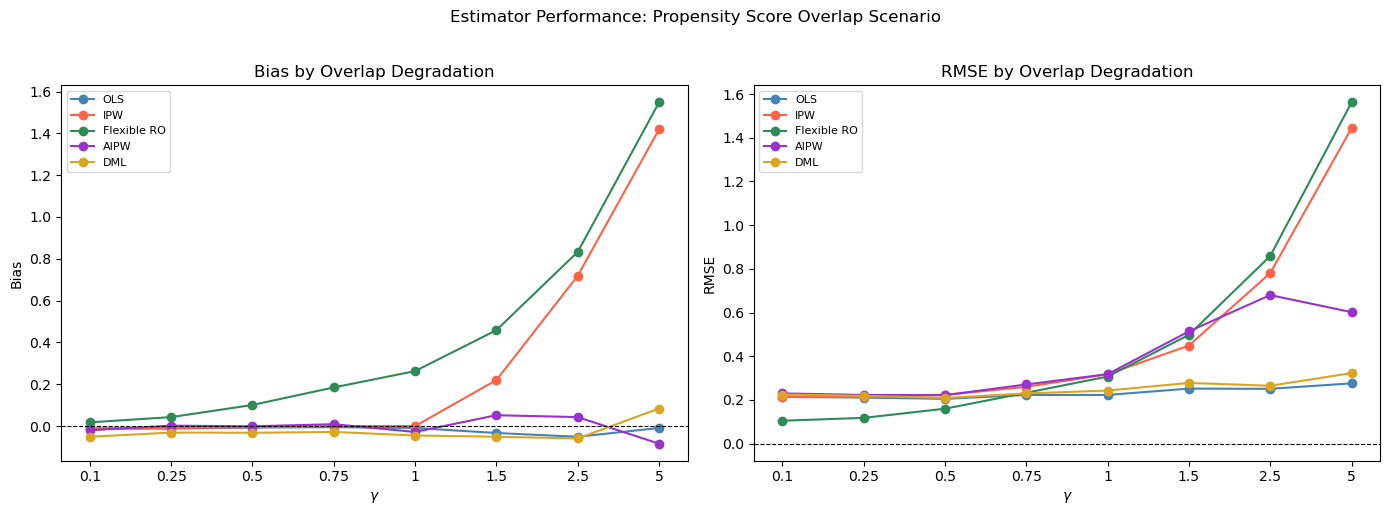

In [5]:
# consistent colour mapping across all scenario plots
estimator_order = ["OLS", "IPW", "Flexible RO", "AIPW", "DML"]
colors = ["steelblue", "tomato", "seagreen", "darkorchid", "goldenrod"]
color_map = dict(zip(estimator_order, colors))

x_pos    = list(range(len(GAMMAS)))
x_labels = [str(g) for g in GAMMAS]

# plot bias and RMSE across gamma values for each estimator
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, ylabel in [("Bias", axes[0], "Bias"), ("RMSE", axes[1], "RMSE")]:
    for name in estimator_order:
        subset = summary[summary["estimator"] == name].sort_values("gamma")
        vals   = subset["RMSE"].values if metric == "RMSE" else subset["Bias"].values
        ax.plot(x_pos, vals, marker="o", label=name, color=color_map[name])

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by Overlap Degradation")
    ax.legend(fontsize=8)

plt.suptitle("Estimator Performance: Propensity Score Overlap Scenario", y=1.02)
plt.tight_layout()
plt.savefig("images/overlap_bias_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

At low $\gamma$ all five estimators appear to recover the true ATE reasonably well. Beyond
$\gamma=1$, their behaviour becomes more differentiated.

- **OLS** appears comparatively stable across the overlap range. Because it adjusts
  directly for $X_0$, it seems to capture much of the confounding signal even as
  treated and control units become more separated. Both bias and RMSE remain fairly flat throughout.

- **IPW** becomes noticeably less stable as overlap weakens. As propensity scores
  move closer to 0 and 1, a relatively small number of observations receive large
  weights and begin to exert more influence on the estimate. In this setting, both
  bias and RMSE increase quite sharply from around $\gamma=1.5$ onward.

- **Flexible RO** shows the largest increase in bias, with bias rising fairly
  steadily across the full $\gamma$ range. A plausible explanation is that the
  separate outcome models are being asked to make predictions in regions with
  limited support from the opposite treatment group. As overlap deteriorates, that
  extrapolation problem appears to become more pronounced, and RMSE increases in
  step with bias.

- **AIPW** remains close to unbiased through about $\gamma=1$ and begins to drift slightly
  at higher values of $\gamma$, becoming modestly negative by $\gamma=5$. This may
  suggest that the outcome model continues to provide some stability, while the
  weighting component becomes more variable as the propensity scores become more
  extreme. RMSE also rises at higher $\gamma$, consistent with reduced overlap.

- **DML** appears comparatively robust in this scenario. Bias remains close to zero
  across most of the range, and RMSE is generally among the lowest of the five
  estimators. In these simulations, that suggests that residualising treatment and
  outcome with respect to $X$ may be less sensitive to overlap deterioration than
  approaches relying more directly on propensity weighting.



### 1c - Diagnostics: Propensity-Reliant Estimators

The bias and RMSE curves indicate *that* some estimators become less reliable as
overlap weakens, but they do not fully show *how* that happens. The next two
diagnostics aim to make those patterns more concrete.

We focus on IPW and AIPW, the two estimators that explicitly estimate and invert
propensity scores as part of the final procedure. DML also models treatment as a
function of $X$, but it does not turn those predictions into inverse weights, so
it is less directly exposed to the instability considered here.

### 1c(i) - IPW Weight Instability

We estimate propensity scores using the same logistic regression specification as
the IPW estimator and compute inverse probability weights for each unit. For
treated units the weight is $1/\hat{ps}_i$, and for control units it is
$1/(1-\hat{ps}_i)$. Weights are clipped to $[0.05, 0.95]$, consistent with the
estimator. The histograms below show the full weight distribution across all
units at each $\gamma$ value.

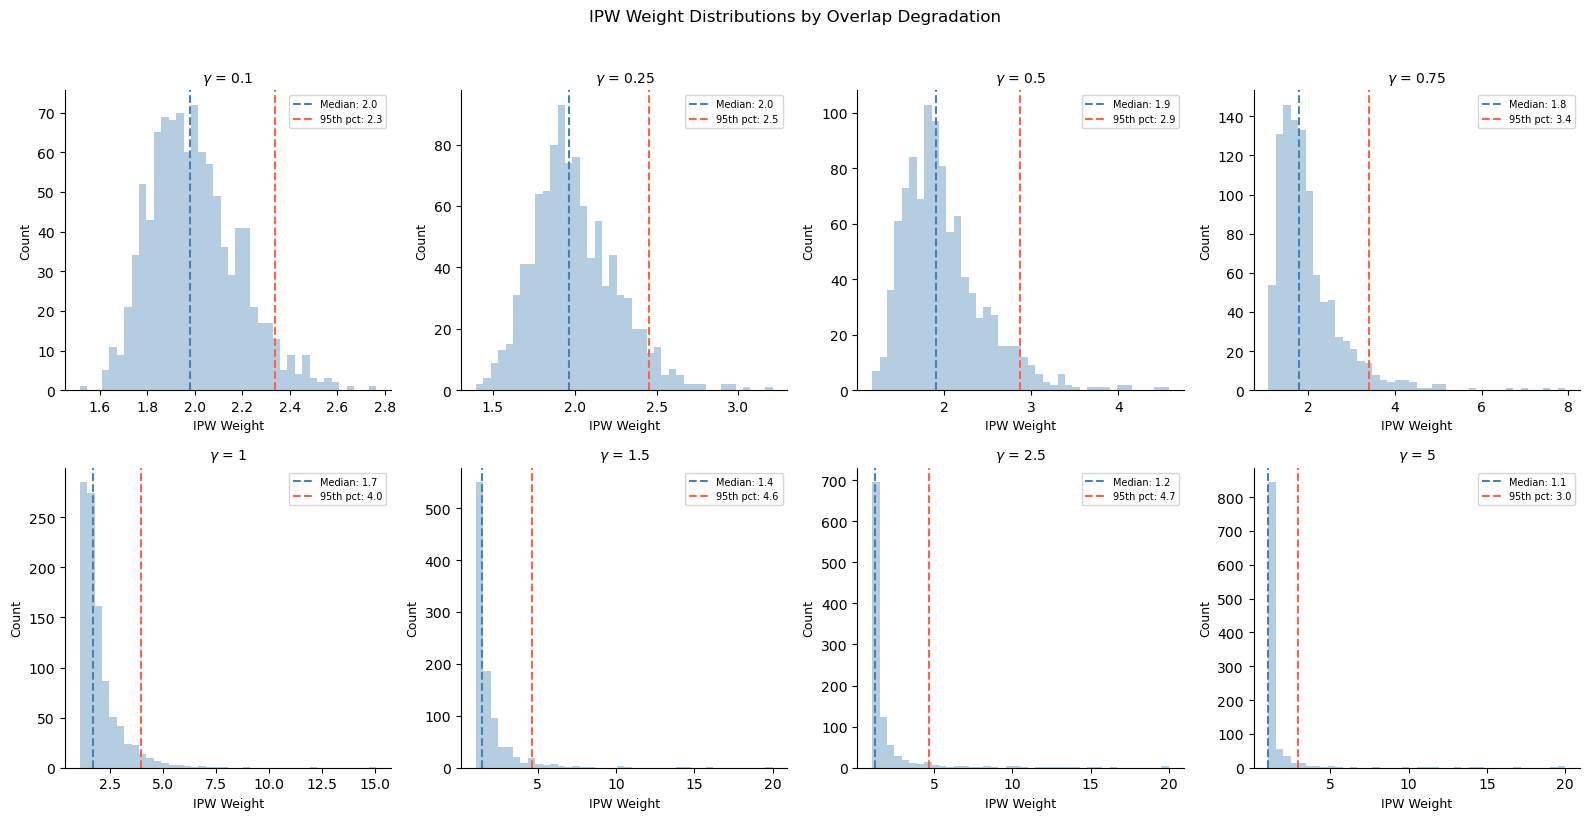

In [6]:
from sklearn.linear_model import LogisticRegression
from ate_suite import PS_CLIP, SEED

# estimate propensity scores and compute IPW weights at each gamma value
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
axes = axes.flatten()

for ax, gamma in zip(axes, GAMMAS):
    Y, T, X, ps = make_overlap_dgp(gamma=gamma)
    ps_hat = (
        LogisticRegression(random_state=SEED)
        .fit(X, T)
        .predict_proba(X)[:, 1]
    )
    ps_hat  = np.clip(ps_hat, *PS_CLIP)
    weights = T / ps_hat + (1 - T) / (1 - ps_hat)

    ax.hist(weights, bins=40, color="steelblue", alpha=0.4, edgecolor="none")
    ax.axvline(np.median(weights), color="steelblue", linewidth=1.5,
               linestyle="--", label=f"Median: {np.median(weights):.1f}")
    ax.axvline(np.percentile(weights, 95), color="tomato", linewidth=1.5,
               linestyle="--", label=f"95th pct: {np.percentile(weights, 95):.1f}")
    ax.set_title(f"$\\gamma$ = {gamma}", fontsize=10)
    ax.set_xlabel("IPW Weight", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)
    
# finalise layout and save
fig.suptitle("IPW Weight Distributions by Overlap Degradation", y=1.02)
plt.tight_layout()
plt.savefig("images/overlap_ipw_weights.png", dpi=150, bbox_inches="tight")
plt.show()

At $\gamma=0.1$, the weights are tightly concentrated near $2.0$, with the 95th
percentile around $2.3$. By $\gamma=1$, the distribution has developed a much
more visible right tail, and the 95th percentile rises to about $4.0$. At higher
$\gamma$, the mass of the distribution shifts downward while the upper tail
remains long, reflecting the effect of clipping together with a growing number of
observations receiving relatively large weights. This pattern is consistent with
the deterioration seen in IPW performance: as overlap weakens, the estimate
appears to become increasingly sensitive to a comparatively small subset of
high-weight observations, rather than being informed more evenly by the full
sample.

### 1c(ii) - Simulation Traces: AIPW vs IPW

Each blue trace represents one of the $N=50$ simulation draws, showing the
estimator's ATE estimate across the eight $\gamma$ values for that particular
dataset. The red line shows the mean estimate across all draws, and the dashed
line marks the true ATE of $2.0$.

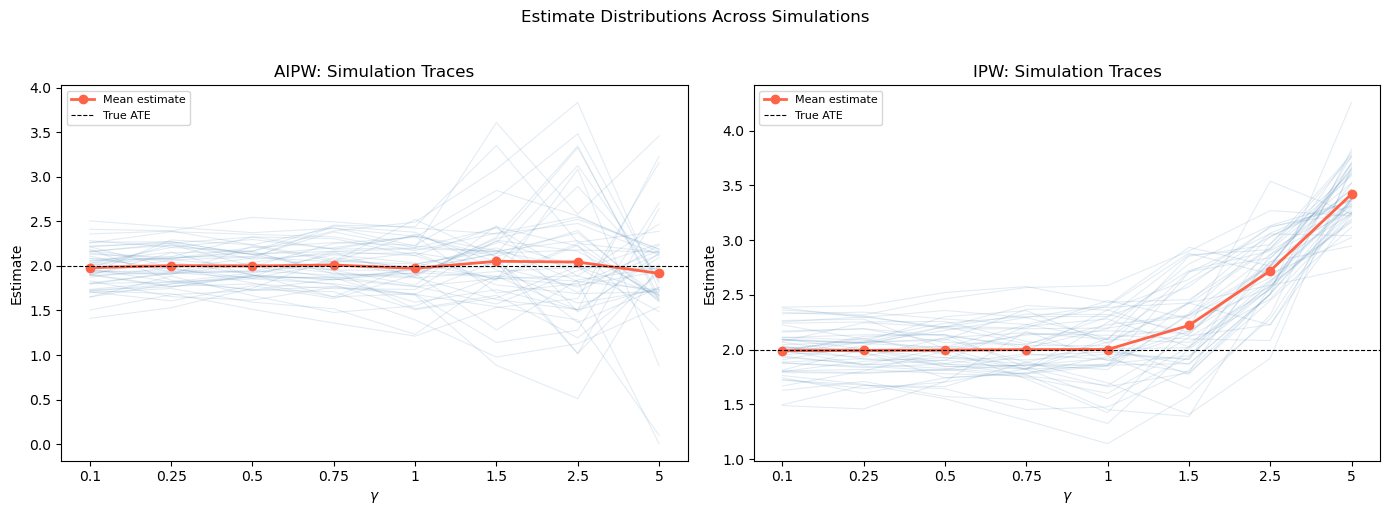

In [7]:
# plot individual simulation traces and mean estimate for AIPW and IPW
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ["AIPW", "IPW"]):
    traces = df[df["estimator"] == name].sort_values("gamma")
    for sim in traces["sim"].unique():
        sim_data = traces[traces["sim"] == sim]
        ax.plot(x_pos, sim_data["estimate"].values,
                color="steelblue", alpha=0.15, linewidth=0.8)
    means = traces.groupby("gamma")["estimate"].mean().values
    ax.plot(x_pos, means, color="tomato", linewidth=2,
            marker="o", label="Mean estimate")
    ax.axhline(TRUE_ATE, color="black", linewidth=0.8,
               linestyle="--", label="True ATE")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Estimate")
    ax.set_title(f"{name}: Simulation Traces")
    ax.legend(fontsize=8)

plt.suptitle("Estimate Distributions Across Simulations", y=1.02)
plt.tight_layout()
plt.savefig("images/overlap_sim_traces.png", dpi=150, bbox_inches="tight")
plt.show()

The simulation traces suggest two somewhat different patterns of deterioration.

- **AIPW** keeps its mean estimate close to $2.0$ through roughly $\gamma=2.5$,
  but the individual traces begin to fan out noticeably as $\gamma$ increases.
  By the highest overlap settings, dispersion is much wider and the mean shifts
  modestly downward. This pattern is consistent with increasing instability across
  samples, with some downward bias emerging only at the most severe levels of
  overlap degradation.

- **IPW** shows a more systematic upward shift. From around $\gamma=1.5$
  onward, both the average estimate and many of the individual traces move above
  the true ATE, and that upward drift becomes pronounced by $\gamma=5$. In this
  case, the figure suggests not just greater variability, but a clearer pattern of
  persistent bias as overlap worsens.

## Scenario 2: Outcome Nonlinearity

The selection-on-observables framework relies on estimators being able to model
the relationship between covariates and outcomes with reasonable accuracy. When
that relationship is linear, OLS is correctly specified and has a natural
advantage. In practice, however, outcome surfaces are often more complex. In this
scenario, we examine how estimator performance changes as the outcome model
becomes progressively more nonlinear, while treatment assignment is held fixed
with healthy overlap throughout so that nonlinearity is the main source of
difficulty.

We introduce a mixing parameter $\alpha$ that interpolates between a purely linear
and a fully nonlinear outcome surface. At $\alpha=0$, OLS is correctly specified
and the setting is relatively benign. As $\alpha$ increases, the outcome surface
incorporates oscillating, cubic, localised, and interaction terms that become
harder for a linear model to capture well.

The sections below describe the DGP, illustrate how the outcome surface changes
across $\alpha$ values, and compare estimator performance in terms of bias and
RMSE.


### 2a - Data Generating Process

The DGP for this scenario is implemented in `make_nonlinear_dgp` in `src/dgp_functions.py`,
accepting `n`, `alpha`, `true_ate`, and `seed` and returning `(Y, T, X, ps)`.

**Covariates:** $X \in \mathbb{R}^{10}$ drawn independently from $\mathcal{N}(0,1)$,
with distinct roles across models:

- $X_0$ — shared confounder, enters both treatment and outcome
- $X_4$, $X_5$ — treatment only
- $X_1$, $X_2$, $X_3$, $X_6$, $X_7$, $X_8$ — outcome only
- $X_9$ — inactive noise

**Treatment assignment** — fixed logistic propensity model with healthy overlap
held constant throughout so that overlap is never the source of stress:

$$ps_i = \sigma(X_{i0} + 0.3\, X_{i4} - 0.2\, X_{i5}), \qquad T_i \sim \text{Bernoulli}(ps_i)$$

**Outcome** — interpolates between a linear and a nonlinear surface via $\alpha$:

$$Y_i = 2.0 \cdot T_i + (1-\alpha) \cdot f_{\text{linear}}(X_i) + \alpha \cdot f_{\text{nonlinear}}(X_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,1)$$

where:

$$f_{\text{linear}}(X) = 3X_0 + 2X_1 + 1.5X_2$$

$$f_{\text{nonlinear}}(X) = 2\sin(X_0) + 0.4X_1^2 - 0.3X_2^3 + 1.5e^{-0.5(X_3^2 + X_4^2)} + 1.5\log(1 + |X_5 + X_6|) + X_7 X_8$$

We evaluate six values $\alpha \in \{0, 0.2, 0.4, 0.6, 0.8, 1.0\}$. At $\alpha=0$
OLS is correctly specified. At $\alpha=1$ the surface combines oscillation,
polynomial curvature, a localised Gaussian bump, log compression, and a bilinear
interaction. Functional form complexity via $\alpha$ is the sole source of
variation across scenarios.

### 2a - Data Generating Process

The DGP for this scenario is implemented in `make_nonlinear_dgp` in `src/dgp_functions.py`,
accepting `n`, `alpha`, `true_ate`, and `seed` and returning `(Y, T, X, ps)`.

**Covariates:** $X \in \mathbb{R}^{10}$ are drawn independently from
$\mathcal{N}(0,1)$, with distinct roles across models:

- $X_0$ — shared confounder, enters both treatment and outcome
- $X_4$, $X_5$ — treatment only
- $X_1$, $X_2$, $X_3$, $X_6$, $X_7$, $X_8$ — outcome only
- $X_9$ — inactive noise

**Treatment assignment** follows a fixed logistic propensity model with overlap held constant throughout:

$$ps_i = \sigma(X_{i0} + 0.3\, X_{i4} - 0.2\, X_{i5}), \qquad T_i \sim \text{Bernoulli}(ps_i)$$

**Outcome** interpolates between a linear and a nonlinear surface via $\alpha$:

$$Y_i = 2.0 \cdot T_i + (1-\alpha) \cdot f_{\text{linear}}(X_i) + \alpha \cdot f_{\text{nonlinear}}(X_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,1)$$

where:

$$f_{\text{linear}}(X) = 3X_0 + 2X_1 + 1.5X_2$$

$$f_{\text{nonlinear}}(X) = 2\sin(X_0) + 0.4X_1^2 - 0.3X_2^3 + 1.5e^{-0.5(X_3^2 + X_4^2)} + 1.5\log(1 + |X_5 + X_6|) + X_7 X_8$$

We consider six values $\alpha \in \{0, 0.2, 0.4, 0.6, 0.8, 1.0\}$. At
$\alpha=0$, OLS is correctly specified. At $\alpha=1$, the outcome surface
combines oscillation, polynomial curvature, a localised Gaussian bump, log
compression, and a bilinear interaction. In this design, $\alpha$ is the main
source of variation across scenarios.

To show more concretely what $\alpha$ does to the outcome surface, we fit OLS
directly to $f(X)$ — the true outcome surface excluding treatment effect and
noise and report $R^2$ at each $\alpha$ value.

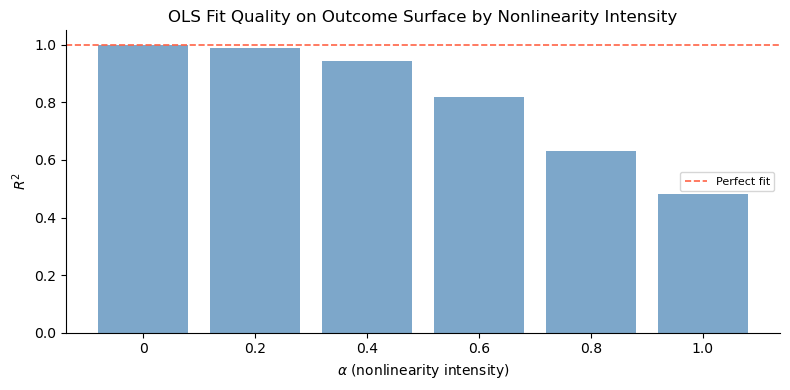

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from dgp_functions import make_nonlinear_dgp

# alpha values defining the degree of nonlinearity
ALPHAS = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

# compute OLS R² on the true outcome surface at each alpha value
r2_scores = []

for alpha in ALPHAS:
    Y, T, X, ps = make_nonlinear_dgp(alpha=alpha)
    f_linear = 3 * X[:, 0] + 2 * X[:, 1] + 1.5 * X[:, 2]
    f_nonlinear = (
        2.0 * np.sin(X[:, 0])
        + 0.4 * X[:, 1]**2
        - 0.3 * X[:, 2]**3
        + 1.5 * np.exp(-0.5 * (X[:, 3]**2 + X[:, 4]**2))
        + 1.5 * np.log1p(np.abs(X[:, 5] + X[:, 6]))
        + 1.0 * X[:, 7] * X[:, 8]
    )
    f_true = (1 - alpha) * f_linear + alpha * f_nonlinear
    f_hat  = LinearRegression().fit(X, f_true).predict(X)
    r2_scores.append(r2_score(f_true, f_hat))

# plot R² by nonlinearity intensity to show OLS fit degradation
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(a) for a in ALPHAS], r2_scores, color="steelblue", alpha=0.7, edgecolor="none")
ax.set_xlabel(r"$\alpha$ (nonlinearity intensity)")
ax.set_ylabel("$R^2$")
ax.set_title("OLS Fit Quality on Outcome Surface by Nonlinearity Intensity")
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="tomato", linewidth=1.2, linestyle="--", label="Perfect fit")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("images/nonlinear_r2.png", dpi=150, bbox_inches="tight")
plt.show()

 At $\alpha=0$, OLS fits
perfectly by construction. As $\alpha$ increases, the nonlinear terms become more
important and OLS fits the surface progressively less well, with $R^2$ falling to
roughly 0.5 at full nonlinearity.

### 2b - Simulation & Results

We run all five estimators across each $\alpha$ value over $N=50$ simulation
draws, varying the random seed across draws to produce stable bias and RMSE
estimates. Treatment assignment is identical across all $\alpha$ values — only
the outcome surface changes. Any divergence in estimator performance is therefore
attributable solely to functional form complexity.

In [9]:
N_SIMS  = 50

# run all estimators across each alpha value for a single simulation draw
def run_sim_nl(sim):
    rows = []
    for alpha in ALPHAS:
        Y, T, X, ps = make_nonlinear_dgp(alpha=alpha, seed=sim)
        for name, fn in ESTIMATORS.items():
            est = fn(Y, T, X)
            rows.append({
                "alpha"    : alpha,
                "estimator": name,
                "sim"      : sim,
                "estimate" : est,
            })
    return rows

# parallelise across simulation draws using all available CPU cores
results = Parallel(n_jobs=-1)(
    delayed(run_sim_nl)(sim) for sim in tqdm(range(N_SIMS), desc="Simulations")
)

# flatten results and compute bias and squared error against true ATE
records_nl = [row for batch in results for row in batch]

df_nl = pd.DataFrame(records_nl)
df_nl["bias"]     = df_nl["estimate"] - TRUE_ATE
df_nl["sq_error"] = df_nl["bias"] ** 2

Simulations: 100%|██████████| 50/50 [00:35<00:00,  1.42it/s]


In [10]:
# aggregate estimates across simulations by alpha and estimator
summary_nl = (
    df_nl.groupby(["alpha", "estimator"])
    .agg(
        ATE      =("estimate", "mean"),
        Bias     =("bias",     "mean"),
        Variance =("estimate", "var"),
        RMSE     =("sq_error", lambda x: x.mean() ** 0.5),
    )
    .round(3)
    .reset_index()
)
# display per-alpha summary tables
for alpha in ALPHAS:
    subset = summary_nl[summary_nl["alpha"] == alpha].drop(columns="alpha")
    subset = subset.set_index("estimator")
    print(f"\nalpha = {alpha}")
    display(subset)


alpha = 0


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.002,0.002,0.005,0.071
DML,1.981,-0.019,0.005,0.071
Flexible RO,2.278,0.278,0.013,0.299
IPW,2.019,0.019,0.019,0.136
OLS,1.996,-0.004,0.004,0.062



alpha = 0.2


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.008,0.008,0.007,0.083
DML,1.984,-0.016,0.006,0.079
Flexible RO,2.193,0.193,0.010,0.217
IPW,2.020,0.020,0.015,0.124
OLS,2.011,0.011,0.005,0.072



alpha = 0.4


...

,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.021,0.021,0.016,0.127
DML,1.988,-0.012,0.013,0.114
Flexible RO,2.084,0.084,0.009,0.126
IPW,2.023,0.023,0.014,0.120
OLS,2.043,0.043,0.011,0.114



alpha = 0.8


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.028,0.028,0.024,0.155
DML,1.994,-0.006,0.019,0.137
Flexible RO,2.055,0.055,0.011,0.119
IPW,2.024,0.024,0.017,0.129
OLS,2.059,0.059,0.016,0.140



alpha = 1.0


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.036,0.036,0.033,0.183
DML,1.993,-0.007,0.025,0.158
Flexible RO,2.059,0.059,0.013,0.128
IPW,2.025,0.025,0.021,0.145
OLS,2.074,0.074,0.023,0.167


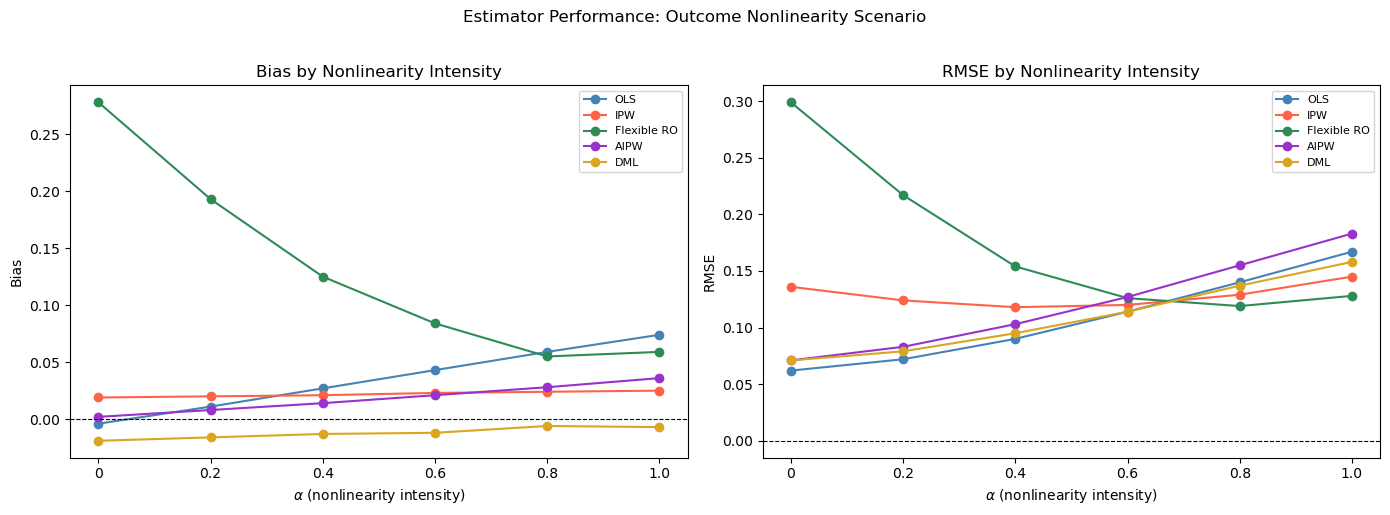

In [11]:
# consistent colour mapping across all scenario plots
estimator_order = ["OLS", "IPW", "Flexible RO", "AIPW", "DML"]
colors          = ["steelblue", "tomato", "seagreen", "darkorchid", "goldenrod"]
color_map       = dict(zip(estimator_order, colors))

x_pos    = list(range(len(ALPHAS)))
x_labels = [str(a) for a in ALPHAS]

# plot bias and RMSE across alpha values for each estimator
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, ylabel in [("Bias", axes[0], "Bias"), ("RMSE", axes[1], "RMSE")]:
    for name in estimator_order:
        subset = summary_nl[summary_nl["estimator"] == name].sort_values("alpha")
        vals   = subset["RMSE"].values if metric == "RMSE" else subset["Bias"].values
        ax.plot(x_pos, vals, marker="o", label=name, color=color_map[name])

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(r"$\alpha$ (nonlinearity intensity)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by Nonlinearity Intensity")
    ax.legend(fontsize=8)

plt.suptitle("Estimator Performance: Outcome Nonlinearity Scenario", y=1.02)
plt.tight_layout()
plt.savefig("images/nonlinear_bias_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

At $\alpha=0$ the outcome surface is purely linear, so the estimators begin from a
relatively favourable setting. As $\alpha$ increases, their performance changes in
different ways.

- **OLS** starts close to unbiased, but bias increases fairly steadily as the
  outcome surface becomes more nonlinear. RMSE rises alongside it, which is
  consistent with growing functional form misspecification.

- **IPW** is comparatively insensitive to $\alpha$ in this scenario. Because it
  does not model the outcome directly, its bias and RMSE remain fairly stable
  across the grid, with only modest movement as nonlinearity increases.

- **Flexible RO** behaves somewhat differently from the other estimators. It
  begins with the largest bias at low $\alpha$, but that bias declines
  substantially as the outcome surface becomes more nonlinear, and its RMSE also
  falls. In context of these simulations, this suggests the flexible outcome model is better
  able to adapt as nonlinear structure becomes more important, although the poor
  performance at low $\alpha$ indicates that flexibility alone is not uniformly an
  advantage.

- **AIPW** shows relatively small bias throughout much of the range, but both bias
  and RMSE increase as $\alpha$ rises. This suggests that the doubly robust
  structure provides some protection at lower levels of nonlinearity, while still
  becoming less stable when the outcome model is increasingly difficult to
  estimate well.

- **DML** remains close to zero bias across the full grid and appears relatively
  robust in this scenario. Its RMSE does increase with $\alpha$, but the
  deterioration is gradual rather than abrupt, suggesting that the residualisation
  approach continues to perform reasonably well even as the outcome surface moves
  further away from linearity.

Overall, this scenario seems to separate methods that rely more heavily on simple
outcome specification from those that can accommodate additional nonlinear
structure. OLS deteriorates most clearly as the surface departs from linearity,
while DML and IPW remain comparatively stable, and Flexible RO appears to benefit
from the richer outcome structure at higher $\alpha$ values.

### 2c - Diagnostics: DML with Flexible Nuisance Models

The results in 2b suggest that DML remains fairly stable overall as $\alpha$
increases, but it is still useful to ask how much that performance depends on the
choice of nuisance model. DML is built around first-stage estimates of the outcome
and treatment processes, so differences in those models can still matter even when
the headline bias pattern looks limited.

To examine this more directly, we rerun DML with `RandomForestRegressor` as the
outcome nuisance model and compare its simulation traces with the original
`LassoCV` specification. This isolates the effect of nuisance model choice while
holding the rest of the DML procedure fixed.

In [12]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV

# two DML variants: linear nuisance (LassoCV) vs flexible nuisance (Random Forest)
def dml_lasso(Y, T, X, seed=SEED):
    est = LinearDML(
        model_y=LassoCV(cv=5, random_state=seed),
        model_t=LogisticRegression(random_state=seed),
        discrete_treatment=True,
        random_state=seed
    )
    est.fit(Y, T, X=X)
    return float(est.ate(X=X))

def dml_forest(Y, T, X, seed=SEED):
    est = LinearDML(
        model_y=RandomForestRegressor(n_estimators=100, random_state=seed),
        model_t=LogisticRegression(random_state=seed),
        discrete_treatment=True,
        random_state=seed
    )
    est.fit(Y, T, X=X)
    return float(est.ate(X=X))

# simulation loop comparing both DML specifications across alpha values
def run_sim_2c(sim):
    rows = []
    for alpha in ALPHAS:
        Y, T, X, ps = make_nonlinear_dgp(alpha=alpha, seed=sim)
        rows.append({"alpha": alpha, "estimator": "DML (LassoCV)",
                     "sim": sim, "estimate": dml_lasso(Y, T, X)})
        rows.append({"alpha": alpha, "estimator": "DML (Forest)",
                     "sim": sim, "estimate": dml_forest(Y, T, X)})
    return rows

# parallelise across simulation draws
results_2c = Parallel(n_jobs=-1)(
    delayed(run_sim_2c)(sim) for sim in tqdm(range(N_SIMS), desc="Simulations")
)

# flatten results and compute bias and squared error
records_2c = [row for batch in results_2c for row in batch]
df_2c      = pd.DataFrame(records_2c)
df_2c["bias"]     = df_2c["estimate"] - TRUE_ATE
df_2c["sq_error"] = df_2c["bias"] ** 2

Simulations: 100%|██████████| 50/50 [00:35<00:00,  1.41it/s]


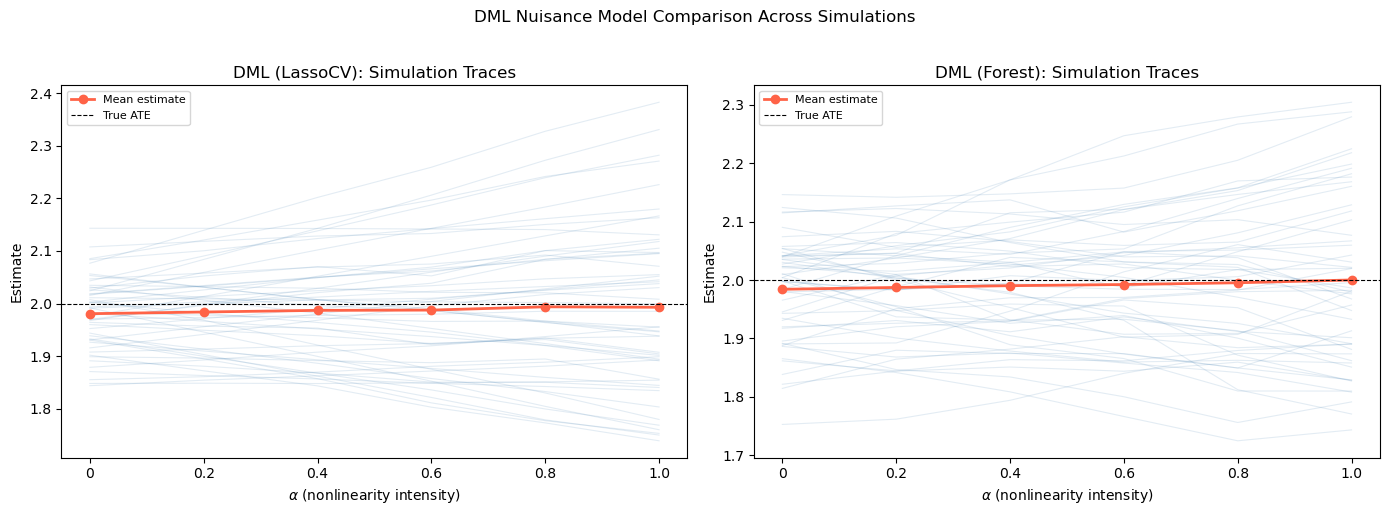

In [13]:
x_pos_nl    = list(range(len(ALPHAS)))
x_labels_nl = [str(a) for a in ALPHAS]

# plot simulation traces for DML (LassoCV) vs DML (Forest) across alpha values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ["DML (LassoCV)", "DML (Forest)"]):
    traces = df_2c[df_2c["estimator"] == name].sort_values("alpha")
    for sim in traces["sim"].unique():
        sim_data = traces[traces["sim"] == sim]
        ax.plot(x_pos_nl, sim_data["estimate"].values,
                color="steelblue", alpha=0.15, linewidth=0.8)
    means = traces.groupby("alpha")["estimate"].mean().values
    ax.plot(x_pos_nl, means, color="tomato", linewidth=2,
            marker="o", label="Mean estimate")
    ax.axhline(TRUE_ATE, color="black", linewidth=0.8,
               linestyle="--", label="True ATE")
    ax.set_xticks(x_pos_nl)
    ax.set_xticklabels(x_labels_nl)
    ax.set_xlabel(r"$\alpha$ (nonlinearity intensity)")
    ax.set_ylabel("Estimate")
    ax.set_title(f"{name}: Simulation Traces")
    ax.legend(fontsize=8)

plt.suptitle("DML Nuisance Model Comparison Across Simulations", y=1.02)
plt.tight_layout()
plt.savefig("images/nonlinear_dml_traces.png", dpi=150, bbox_inches="tight")
plt.show()

Both specifications show noticeable variation across individual draws,
which is consistent with ordinary estimation uncertainty in a setting with a
nonlinear outcome surface. In this figure, however, the main difference is fairly
subtle and appears more in the distribution of traces than in the average estimate.

- **DML (LassoCV)** keeps its mean estimate close to $2.0$ across the full
  $\alpha$ grid. The individual traces do spread out somewhat, which suggests that
  the linear nuisance model becomes a less exact approximation as the outcome
  surface grows more complex, even though the average estimate remains quite
  stable.

- **DML (Forest)** also remains centred very near $2.0$ throughout. Its mean
  estimate is, if anything, slightly flatter across $\alpha$, which is consistent
  with the flexible nuisance model adapting more naturally to the nonlinear
  outcome surface. At the same time, the overall pattern is quite similar to the
  LassoCV version, so the difference here looks incremental rather than dramatic.

A more flexible outcome model may provide some additional protection as nonlinearity
increases, while the broader DML approach itself remains reasonably robust across
the range considered here.

## Scenario 3: High Dimensionality

In the previous two scenarios the covariate space was fixed at ten dimensions.
In practice, researchers often observe many more variables than are actually
relevant e.g. digital user activity datasets may contain hundreds or thousands of potential controls. Including all of them is the safe choice from an identification standpoint, but can create
estimation challenges that vary dramatically across methods.

In this scenario we increase the total number of covariates $p$ while holding the number of truly informative covariates fixed at $k=5$. The remaining $p-k$ covariates are noise variables with no direct effect on treatment or outcome, but they are weakly correlated with $X_0$ and can therefore appear spuriously predictive. Treatment assignment and the outcome structure are held fixed throughout so that
dimensionality is the sole source of estimator stress.

The sections below set out the DGP, the noise-to-signal ratio across $p$ values,
and estimator performance in terms of bias and RMSE.

### 3a. Data Generating Process

The DGP for this scenario is implemented in `make_highdim_dgp` in `src/dgp_functions.py`,
accepting `n`, `p`, `k`, `true_ate`, and `seed` and returning `(Y, T, X, ps)`.

**Covariates:** $X \in \mathbb{R}^{p}$ with two distinct groups:

- $X_0$ through $X_4$ — the $k=5$ informative covariates, drawn independently from $\mathcal{N}(0,1)$
- $X_5$ through $X_{p-1}$ — noise covariates, weakly correlated with $X_0$ via $\rho=0.3$

The noise covariates have no true effect on treatment or outcome but their
correlation with $X_0$ makes them look like confounders to naive methods. An estimator that includes them without selection may pick up spurious signal and can become less stable as dimensionality grows. An estimator with regularisation should down-weight or zero them out.

**Treatment assignment** — driven by informative covariates only:

$$ps_i = \sigma(X_{i0} + 0.3\, X_{i1} - 0.2\, X_{i2}), \qquad T_i \sim \text{Bernoulli}(ps_i)$$

**Outcome** — linear in the five informative covariates only:

$$Y_i = 2.0 \cdot T_i + 3X_{i0} + 2X_{i1} + 1.5X_{i2} + X_{i3} + 0.5X_{i4} + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,1)$$

We evaluate six values $p \in \{5, 10, 25, 50, 75, 100\}$. At $p=5$ there
are no noise variables and all estimators operate cleanly. As $p$ grows the
noise pool expands and methods that cannot distinguish signal from correlated
noise begin to accumulate bias and variance. The evaluation is capped at $p=100$, since propensity-based methods
would likely require more specialised high-dimensional treatment models beyond
this point.

In [14]:
from dgp_functions import make_highdim_dgp

DIMS = [5, 10, 25, 50, 75, 100]
K    = 5  # number of truly informative covariates, fixed throughout

Before running the estimators we visualise the noise-to-signal ratio across $p$
values. For each $p$ we fit a LassoCV model on $Y$ regressed on $X$ and plot
the proportion of selected variables that are genuinely informative versus noise.

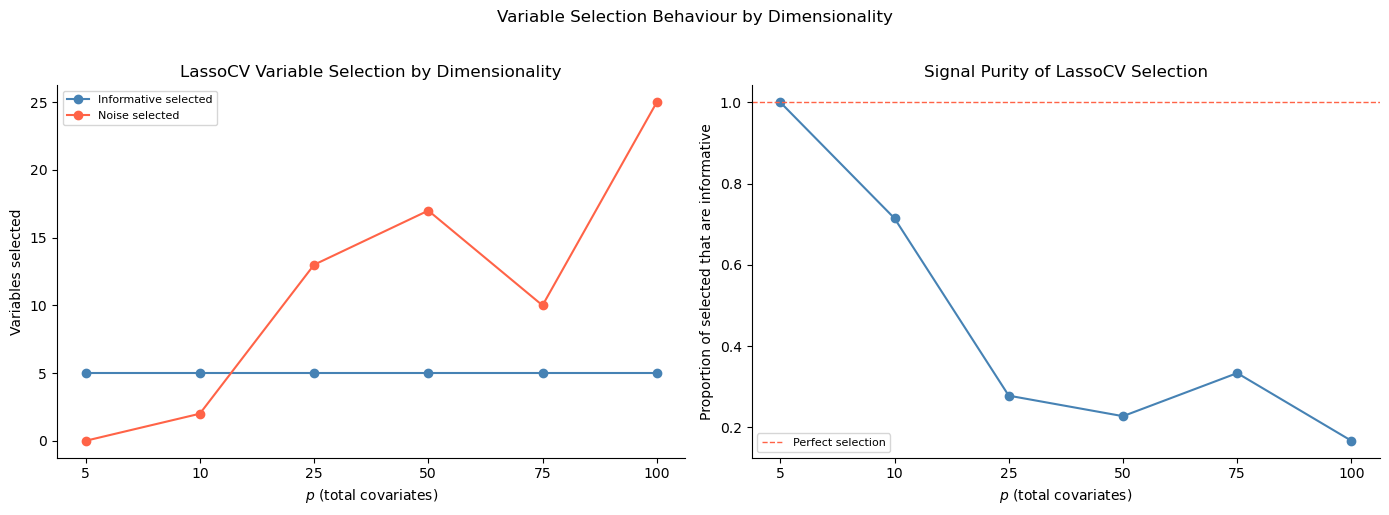

In [15]:
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt
import numpy as np

# fit LassoCV at each p value and count informative vs noise variables selected
signal_ratios = []
noise_selected = []
signal_selected = []

for p in DIMS:
    Y, T, X, ps = make_highdim_dgp(p=p, k=K)
    lasso = LassoCV(cv=3, random_state=SEED).fit(X, Y)
    coefs = np.abs(lasso.coef_)
    selected = coefs > 0
    n_signal = selected[:K].sum()
    n_noise  = selected[K:].sum()
    signal_selected.append(n_signal)
    noise_selected.append(n_noise)
    signal_ratios.append(n_signal / max(selected.sum(), 1))
    
# plot variable selection counts and signal purity across dimensionality levels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(len(DIMS)), signal_selected, marker="o",
             color="steelblue", label="Informative selected")
axes[0].plot(range(len(DIMS)), noise_selected, marker="o",
             color="tomato", label="Noise selected")
axes[0].set_xticks(range(len(DIMS)))
axes[0].set_xticklabels([str(p) for p in DIMS])
axes[0].set_xlabel("$p$ (total covariates)")
axes[0].set_ylabel("Variables selected")
axes[0].set_title("LassoCV Variable Selection by Dimensionality")
axes[0].legend(fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(range(len(DIMS)), signal_ratios, marker="o",
             color="steelblue")
axes[1].axhline(1.0, color="tomato", linewidth=1.0, linestyle="--",
                label="Perfect selection")
axes[1].set_xticks(range(len(DIMS)))
axes[1].set_xticklabels([str(p) for p in DIMS])
axes[1].set_xlabel("$p$ (total covariates)")
axes[1].set_ylabel("Proportion of selected that are informative")
axes[1].set_title("Signal Purity of LassoCV Selection")
axes[1].legend(fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Variable Selection Behaviour by Dimensionality", y=1.02)
plt.tight_layout()
plt.savefig("images/highdim_variable_selection.png", dpi=150, bbox_inches="tight")
plt.show()

In this diagnostic run, Lasso recovers all five informative covariates at every $p$ value, but noise contamination grows substantially with dimensionality.

### 3b - Simulation & Results

We run all five estimators across each $p$ value over $N=50$ simulation draws.
The informative covariate set is fixed at $k=5$ throughout — only the noise
pool grows. Any divergence in estimator performance is attributable solely to
the curse of dimensionality and each method's ability to handle irrelevant
covariates.

In [16]:
N_SIMS = 50

# run all estimators across each p value for a single simulation draw
def run_sim_hd(sim):
    rows = []
    for p in DIMS:
        Y, T, X, ps = make_highdim_dgp(p=p, k=K, seed=sim)
        for name, fn in ESTIMATORS.items():
            est = fn(Y, T, X)
            rows.append({
                "p"        : p,
                "estimator": name,
                "sim"      : sim,
                "estimate" : est,
            })
    return rows

# parallelise across simulation draws using all available CPU cores
results_hd = Parallel(n_jobs=-1)(
    delayed(run_sim_hd)(sim) for sim in tqdm(range(N_SIMS), desc="Simulations")
)
# flatten results and compute bias and squared error against true ATE
records_hd = [row for batch in results_hd for row in batch]
df_hd = pd.DataFrame(records_hd)
df_hd["bias"]     = df_hd["estimate"] - TRUE_ATE
df_hd["sq_error"] = df_hd["bias"] ** 2

Simulations: 100%|██████████| 50/50 [01:40<00:00,  2.02s/it]


In [17]:
# aggregate estimates across simulations by p and estimator
summary_hd = (
    df_hd.groupby(["p", "estimator"])
    .agg(
        ATE      =("estimate", "mean"),
        Bias     =("bias",     "mean"),
        Variance =("estimate", "var"),
        RMSE     =("sq_error", lambda x: x.mean() ** 0.5),
    )
    .round(3)
    .reset_index()
)
# display per-p summary tables
for p in DIMS:
    subset = summary_hd[summary_hd["p"] == p].drop(columns="p")
    subset = subset.set_index("estimator")
    print(f"\np = {p}")
    display(subset)


p = 5


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,1.975,-0.025,0.005,0.077
DML,1.972,-0.028,0.005,0.076
Flexible RO,2.299,0.299,0.013,0.320
IPW,2.004,0.004,0.017,0.130
OLS,1.981,-0.019,0.005,0.074



p = 10


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,1.995,-0.005,0.008,0.087
DML,1.987,-0.013,0.005,0.075
Flexible RO,2.363,0.363,0.016,0.384
IPW,2.042,0.042,0.021,0.150
OLS,1.998,-0.002,0.005,0.069



p = 25


...

,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.057,0.057,0.025,0.167
DML,1.896,-0.104,0.008,0.135
Flexible RO,2.432,0.432,0.020,0.453
IPW,2.081,0.081,0.025,0.177
OLS,2.018,0.018,0.006,0.078



p = 75


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.096,0.096,0.071,0.280
DML,1.778,-0.222,0.007,0.238
Flexible RO,2.419,0.419,0.022,0.444
IPW,2.056,0.056,0.028,0.175
OLS,1.995,-0.005,0.005,0.071



p = 100


,ATE,Bias,Variance,RMSE
estimator,,,,
AIPW,2.314,0.314,0.385,0.690
DML,1.708,-0.292,0.006,0.302
Flexible RO,2.460,0.460,0.029,0.489
IPW,2.102,0.102,0.028,0.195
OLS,2.003,0.003,0.004,0.063


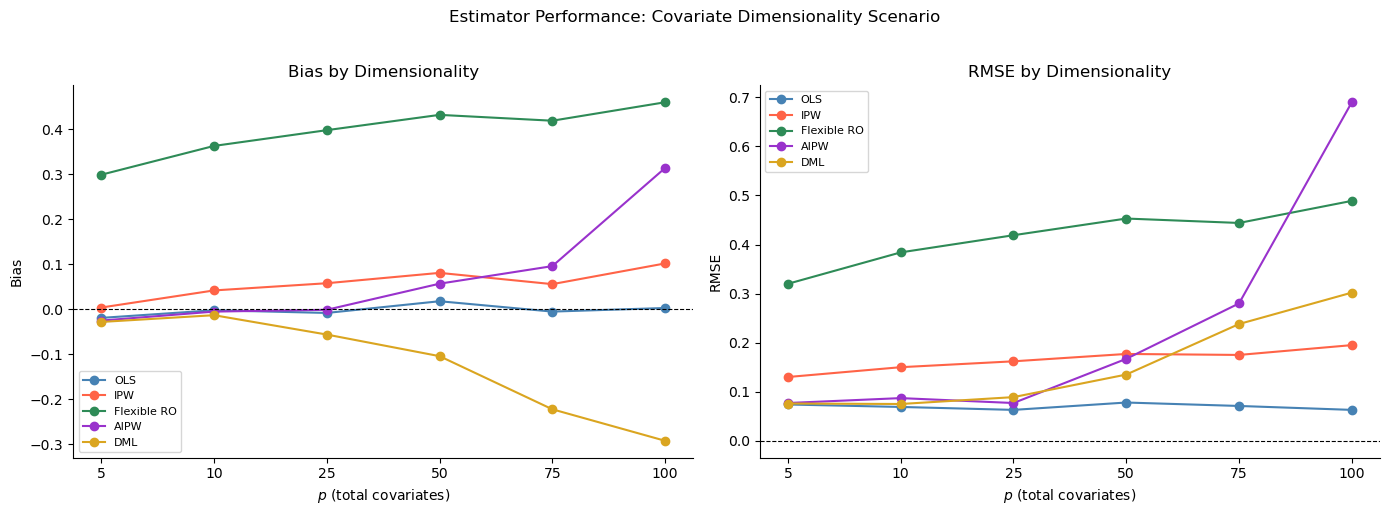

In [18]:
# consistent colour mapping across all scenario plots
estimator_order = ["OLS", "IPW", "Flexible RO", "AIPW", "DML"]
colors          = ["steelblue", "tomato", "seagreen", "darkorchid", "goldenrod"]
color_map       = dict(zip(estimator_order, colors))

x_pos    = list(range(len(DIMS)))
x_labels = [str(p) for p in DIMS]

# plot bias and RMSE across p values for each estimator
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, ylabel in [("Bias", axes[0], "Bias"), ("RMSE", axes[1], "RMSE")]:
    for name in estimator_order:
        subset = summary_hd[summary_hd["estimator"] == name].sort_values("p")
        vals   = subset["RMSE"].values if metric == "RMSE" else subset["Bias"].values
        ax.plot(x_pos, vals, marker="o", label=name, color=color_map[name])

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("$p$ (total covariates)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by Dimensionality")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Estimator Performance: Covariate Dimensionality Scenario", y=1.02)
plt.tight_layout()
plt.savefig("images/highdim_bias_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

The results suggest a fairly clear split between estimators as dimensionality
increases. 

- **OLS** remains close to zero bias throughout and has the lowest RMSE across
  the grid. In this setting, the linear outcome structure appears to let OLS
  absorb the relevant signal without being heavily distorted by the additional
  correlated noise covariates.

- **IPW** shows a modest but fairly steady increase in both bias and RMSE as $p$
  grows. By $p=100$, the deterioration is visible but not extreme, suggesting
  that the estimated propensity model becomes less clean in higher dimensions
  without completely breaking down over the range considered here.

- **Flexible RO** has the largest bias throughout and worsens gradually as
  dimensionality increases. Its RMSE follows a similar pattern. In these
  simulations, the forest-based outcome models do not appear to separate the
  informative signal from the growing pool of correlated noise especially well,
  which is consistent with weaker counterfactual prediction in higher dimensions.

- **AIPW** is fairly stable up to about $p=50$, but then deteriorates noticeably
  at $p=75$ and especially at $p=100$. Both bias and RMSE rise sharply in the
  highest-dimensional settings, suggesting that the doubly robust correction
  becomes much less stable once the nuisance models have to contend with a large
  number of correlated but non-causal covariates.

- **DML** also deteriorates as dimensionality grows, though in a different way.
  Its RMSE rises steadily and bias becomes increasingly negative at higher $p$.
  This suggests that regularisation helps, but does not fully protect the
  first-stage models from the growing noise-to-signal ratio in this design.

Overall, this scenario appears least favourable to the estimators that rely on
more complex nuisance estimation without a strong mechanism for isolating the
small informative subset. OLS remains the most stable here, while AIPW and DML
show the clearest late-stage deterioration as $p$ becomes large.

### 3c - Diagnostics: DML vs AIPW Simulation Traces

Both DML and AIPW are doubly robust estimators, yet their performance diverges sharply at high $p$. The reason lies in how each handles the growing noise pool. The figure below compares their simulation-by-simulation behaviour across the six $p$ values.

The variable selection diagnostic in 3a suggests that regularisation continues to recover the informative covariates, but with growing contamination from correlated noise as dimensionality increases. That pattern is helpful for interpreting the trace plots here: the main issue is not simply whether signal is present, but how well each estimator's nuisance components remain anchored as the noise-to-signal
ratio worsens.

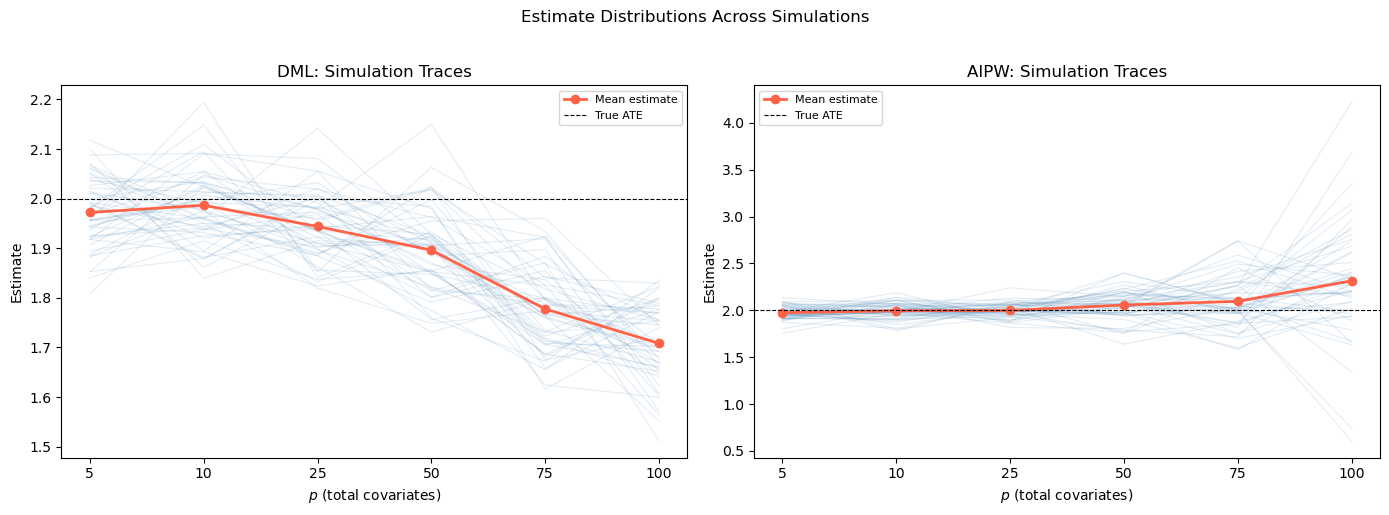

In [19]:
x_pos_hd    = list(range(len(DIMS)))
x_labels_hd = [str(p) for p in DIMS]

# plot individual simulation traces and mean estimate for DML and AIPW across p values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ["DML", "AIPW"]):
    traces = df_hd[df_hd["estimator"] == name].sort_values("p")
    for sim in traces["sim"].unique():
        sim_data = traces[traces["sim"] == sim]
        ax.plot(x_pos_hd, sim_data["estimate"].values,
                color="steelblue", alpha=0.15, linewidth=0.8)
    means = traces.groupby("p")["estimate"].mean().values
    ax.plot(x_pos_hd, means, color="tomato", linewidth=2,
            marker="o", label="Mean estimate")
    ax.axhline(TRUE_ATE, color="black", linewidth=0.8,
               linestyle="--", label="True ATE")
    ax.set_xticks(x_pos_hd)
    ax.set_xticklabels(x_labels_hd)
    ax.set_xlabel("$p$ (total covariates)")
    ax.set_ylabel("Estimate")
    ax.set_title(f"{name}: Simulation Traces")
    ax.legend(fontsize=8)

plt.suptitle("Estimate Distributions Across Simulations", y=1.02)
plt.tight_layout()
plt.savefig("images/highdim_sim_traces.png", dpi=150, bbox_inches="tight")
plt.show()

The trace plots suggest different high-dimensional failure modes.

- **DML** shows a fairly tight band of estimates throughout, but the whole band
  shifts downward as $p$ increases. This points more to a systematic negative
  drift than to a large increase in simulation-to-simulation instability. A plausible explanation is that, as dimensionality grows, the Lasso nuisance models begin to absorb more correlated noise alongside the true signal. That would not necessarily make DML highly erratic, but it could introduce a systematic shrinkage-driven distortion in the residualisation step, which is consistent with the gradual downward drift seen here.

- **AIPW** stays well centred through about $p=50$, but then the traces spread
  out sharply at higher dimensions. By $p=100$, the mean has moved upward and the
  dispersion is much wider, suggesting a mix of rising variance and upward bias.

In short, DML appears to deteriorate mainly through directional drift, whereas AIPW becomes much more sample-sensitive in the largest models.

## Conclusion

This notebook compared five causal estimators across three controlled DGP
scenarios where the true ATE is known by construction. By varying one source of
stress at a time, it became easier to relate changes in estimator performance to
specific features of the data-generating process.

Across the simulations, the main pattern is that estimator weaknesses appear to
be structural rather than random. Propensity-based methods become less stable as
overlap weakens and weights become more extreme. Outcome-based methods can
struggle when treated and control models are asked to predict across poorly
represented regions. In higher-dimensional settings, nuisance estimation becomes
harder once a small informative signal is surrounded by many correlated but
non-causal covariates. Doubly robust methods remain appealing, but their
practical performance still depends on the quality of their internal nuisance
models.

There are several natural extensions to this framework.

- One is to move from ATE to CATE estimation, where the target becomes a
  function rather than a scalar and the estimator class can be expanded to
  include methods such as causal forests.
- Another is to introduce additional DGP stresses, such as stronger
  confounding, treatment effect heterogeneity, or alternative outcome
  structures in the high-dimensional setting.
- On the estimator side, it would also be useful to test variants designed for
  particular failure modes, such as more explicit regularisation in
  high-dimensional propensity modelling, or to compare against other classes of
  methods such as matching or ensemble approaches.

The broader lesson is that, even when identification is available under
selection on observables, estimator choice still matters. Deciding which method
to trust depends on which assumptions seem most credible in the data at hand,
and on which failure modes are most likely to matter in practice.